# Lab 4.02 - Bivariate Analysis of Qualitative Data

In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 2 - NBA Salaries

The file NBA.csv contains annual salaries for all NBA basketball players in the season (2008–2009), check whether there is independence between position and salary. To do this, first change any hyphenated position such as C-F to 
the first listed, in this case C. (Presumably, this is 
the player's primary position.)     
Then remove $ and . in Annual Salary and make Annual Salary categorical with four categories: the first is all salaries below the first quartile, the second is all salaries from the first quartile to the median, and so on.  
First make a plot

Results of the main calculations:
  - χ² ≈ 3.0344 
  - p-value = 0.8045
  - We do not reject H0



In [2]:
nba = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/NBA.csv', sep=";")
nba.head(10)

,Player,Team,Position,Annual Salary,Contract Yrs,Contract Amt,Contract Thru
0,"Bibby, Mike",Atlanta Hawks,G,$14.983.603,1,$14.983.603,2008-09
1,"Johnson, Joe",Atlanta Hawks,G,$14.232.566,5,$70.000.000,2009-10
2,"Smith, Josh",Atlanta Hawks,F,$10.000.000,5,$58.000.000,2012-13
3,"Claxton, Speedy",Atlanta Hawks,G,$5.757.818,4,$25.000.000,2010-11
4,"Williams, Marvin",Atlanta Hawks,F,$5.636.142,4,$18.160.000,2008-09(t)
5,"Horford, Al",Atlanta Hawks,C-F,$4.023.720,3,$12.080.160,2009-10
6,"Pachulia, Zaza",Atlanta Hawks,C,$4.000.000,4,$16.000.000,2008-09
7,"Evans, Maurice",Atlanta Hawks,F-G,$2.500.000,3,$7.500.000,2010-11
8,"Law, Acie",Atlanta Hawks,G,$2.071.680,3,$6.214.920,2009-10
9,"Murray, Ronald",Atlanta Hawks,G,$1.500.000,1,$1.500.000,2008-09


In [3]:
# Clean Position: keep only the first part before the hyphen
nba['Position'] = nba['Position'].str.split('-').str[0]

# Clean Annual Salary: remove '$' and '.', then convert to numeric
# Note: The data uses '.' as a thousands separator, so we replace it
nba['Annual Salary'] = nba['Annual Salary'].str.replace('$', '', regex=False)
nba['Annual Salary'] = nba['Annual Salary'].str.replace('.', '', regex=False)
nba['Annual Salary'] = pd.to_numeric(nba['Annual Salary'])

In [ ]:
# Determine quartile boundaries
quantiles = nba['Annual Salary'].quantile([0.25, 0.5, 0.75])

# Define bins and labels
bins = [0, quantiles[0.25], quantiles[0.5], quantiles[0.75], nba['Annual Salary'].max()]
labels = ['Q1', 'Q2', 'Q3', 'Q4']

# Create categorical column
nba['Salary Category'] = pd.cut(nba['Annual Salary'], bins=bins, labels=labels, include_lowest=True)

<Figure size 1000x800 with 0 Axes>

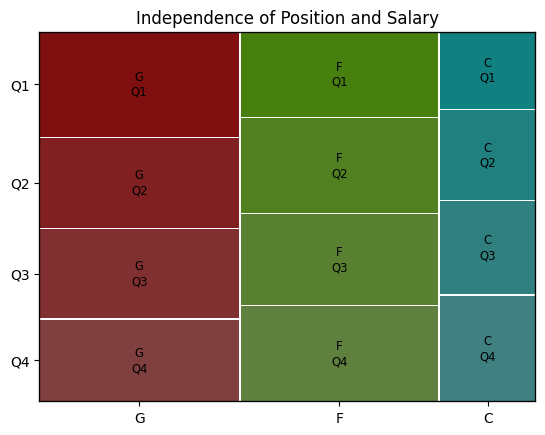

Chi-square: 3.0774
p-value: 0.7991


In [22]:
# Create a mosaic plot
plt.figure(figsize=(10, 8))
mosaic(nba, ['Position', 'Salary Category'], title='Independence of Position and Salary')
plt.show()

# Perform Chi-square test
contingency_table = pd.crosstab(nba['Position'], nba['Salary Category'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p:.4f}")